In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from scipy import stats

In [48]:
df = pd.read_csv('WA_Marketing-Campaign.csv')

In [49]:
df

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81
...,...,...,...,...,...,...,...
543,10,Large,919,2,1,4,64.34
544,10,Large,920,14,2,1,50.20
545,10,Large,920,14,2,2,45.75
546,10,Large,920,14,2,3,44.29


**Part 1**
1) By randomly assigning promotions to the stores, the experiment can minimize the potential for confounding variables in the experiment. For instance, if the stores volunteered to participate in different promotions, the results would be confused with other variables, such as the entrprenuership or workplace cultures or different stores. 
2) LocationID (the store) is the experimental unit; Promotion (which promotion used) is the treatment; and SalesInThousands (the sales following the promotion) is the outcome. 
3) This is primarily an inference problem because the survey is designed to statistically test whether an different actions produce significantly different results. The future outcomes are not being predicted.   

**Part 2**
1) Plot below.

<Axes: xlabel='SalesInThousands', ylabel='Promotion'>

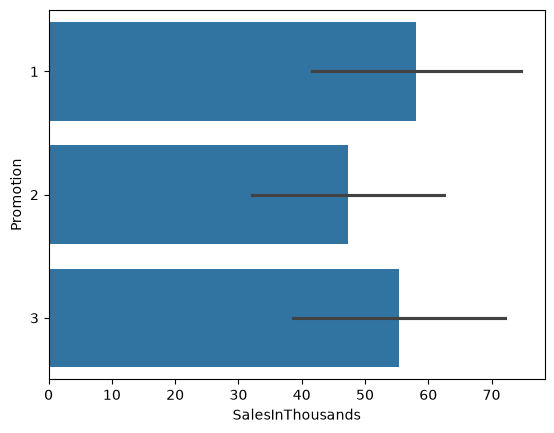

In [50]:
df.groupby('Promotion')['SalesInThousands'].mean()
plot_1 = sns.barplot(
    data=df, 
    x='SalesInThousands', 
    y='Promotion', 
    orient='h', 
    errorbar='sd')
plot_1

2) It appears that Promotion 2 is associated with slightly less average sales than Promotions 1 or 3, but the difference is not very large. Additionally, the standard deviation of each group is relatively large in porportion to their respective average sales.  
3) Given the extensive overlap of each promotion's respective standard deviations, I cannot conclude just by looking at the graph whether there is any real difference in outcomes between the different promotions. 

**Part 3**
1) Theta represents the difference in average sales between the population of stores participating in Promotion 2 and those in Promotion 1. If Theta > 0, then Promotion 2 stores have sold more on average than Promotion 1 stores, and Promotion 2 is more effective. Vice versa is Theta < 0, Promotion 1 would be more effective than Promotion 2. If Theta = 0, then there is no difference between the outcomes of the different promotions. 
2) *Code below*


In [51]:
df.groupby('Promotion')['SalesInThousands'].mean()

Promotion
1    58.099012
2    47.329415
3    55.364468
Name: SalesInThousands, dtype: float64

In [52]:
theta2_1 = df.groupby('Promotion')['SalesInThousands'].mean()[2] - df.groupby('Promotion')['SalesInThousands'].mean()[1]
theta2_1

np.float64(-10.769596734289962)

3) Theta = -10.77, which means that the sample mean sales of Promotion 1 stores is $10 thousand dollars more than the sample mean of Promotion 2 stores. 

4) *Code below*

In [53]:
p1_sales = df.loc[df["Promotion"] == 1, "SalesInThousands"].to_numpy()
p2_sales = df.loc[df["Promotion"] == 2, "SalesInThousands"].to_numpy()
mean_sales_diff = p2_sales.mean()-p1_sales.mean()

In [54]:
rng = np.random.default_rng(7787)
B = 5000

boot_sales_diff = np.empty(B)

for b in range(B):

    p1_star = rng.choice(
        p1_sales,
        size=len(p1_sales),
        replace=True
    )

    p2_star = rng.choice(
        p2_sales,
        size=len(p2_sales),
        replace=True
    )

    boot_sales_diff[b] = (
        p2_star.mean()
        - p1_star.mean()
    )

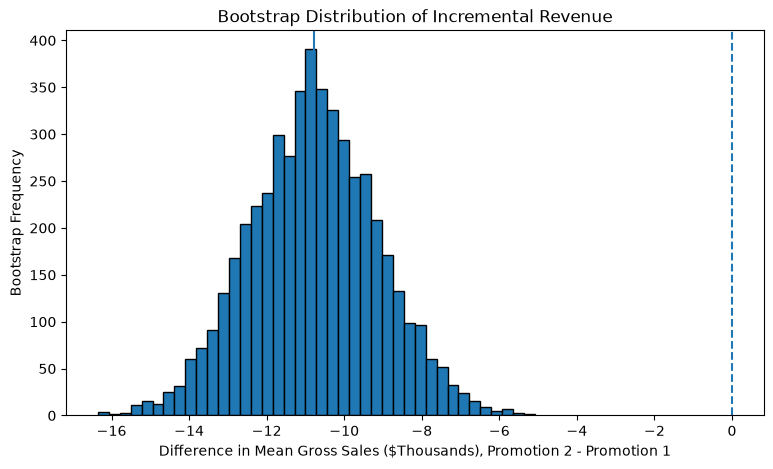

In [55]:
plt.figure(figsize=(9,5))

plt.hist(
    boot_sales_diff,
    bins=40,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.axvline(
    mean_sales_diff
)

plt.xlabel(
    "Difference in Mean Gross Sales ($Thousands), Promotion 2 - Promotion 1"
)

plt.ylabel(
    "Bootstrap Frequency"
)

plt.title(
    "Bootstrap Distribution of Incremental Revenue"
)

plt.show()

In [56]:
lower, upper = np.percentile(
    boot_sales_diff,
    [2.5, 97.5]
)

print(
    f"Difference of mean sales: "
    f"${mean_sales_diff:.2f}"
)

print(
    f"95% bootstrap CI: "
    f"[${lower:.2f}, ${upper:.2f}]"
)

Difference of mean sales: $-10.77
95% bootstrap CI: [$-14.00, $-7.52]


5) The confidence interval ($-14.00, $-7.52) means that in 95% of resamples, the mean sales of the Promotion 2 group is $7.5 thousand to $14 thousand dollars greater than the mean sales of the Promotion 1 group. By extension, this can be interpreted that if promotions had no effect on sales whatsoever, it would be a less-than-5% liklihood that this distribution could be produced by random deviation, because 0 does not fall within the bounds of the confidence 95% confidence interval. 
In other words, we can say that the Promotion 2 group has significantly more sales on average than the Promotion 1 group. 

6) If the confidence interval contained 0, this would mean that there is a 5% or greater liklihood that random variance between the two sample means could lead to the distribution. In this case, we could not reliably claim that promotional campaigns are linked to sales because there is a greater-than-5% chance that there is no relationship at all; and we are not willing to hazard such a risky statement. 

**Part 4**

1) Yes, there is strong evidence that Promotion 2 increased weekly sales compared to Promotion 1. Though there is no control group, and we cannot compare Promotion 2's effects to no promotion, we can still compare between the groups that were tested in the experiment.

2) Yes, there is strong evidence that Promotion 2 increased weekly sales by more than $2 thousand on average compared to Promotion 1. The confidence interval, as described above in part 3, establishes that Promotion 2 increased average sales by $7.5 to $14 thousand weekly.

3) My recommendation adopt Promotion 2 over Promotion 1. We cannot make a reference with respect to Promotion 3 yet, however, because that has not been tested against Promotion 2 to establish a heirarchy of the different promotion schemes. But if the company is only deciding between 1 and 2, they should adopt Promotion 2 due to its high estimated efficacy ($7.5 to $14 thousand more weekly sales than Promotion 1) and its low uncertainty (less than a 5% chance that Promotion 2's apparent supremacy is the result of random chance).

**Part 5**

In [58]:
p3_sales = df.loc[df["Promotion"] == 3, "SalesInThousands"].to_numpy()
p3_sales

array([33.73, 35.67, 29.03, 39.25, 32.9 , 22.18, 42.98, 26.68, 33.42,
       37.93, 33.85, 40.25, 61.59, 63.64, 54.68, 61.24, 62.93, 58.77,
       70.6 , 65.06, 59.76, 66.11, 62.16, 64.04, 59.65, 57.04, 59.73,
       56.72, 58.55, 62.19, 53.14, 62.27, 86.14, 82.56, 79.36, 77.17,
       89.7 , 78.43, 84.05, 81.18, 83.02, 90.3 , 85.18, 89.77, 82.64,
       82.89, 82.13, 88.91, 87.7 , 81.16, 81.58, 94.21, 96.48, 84.13,
       91.98, 81.72, 84.34, 87.9 , 76.12, 82.72, 94.89, 74.75, 93.63,
       80.82, 91.61, 79.02, 86.11, 82.88, 51.47, 53.47, 46.83, 56.7 ,
       52.23, 51.68, 46.22, 46.03, 45.56, 55.19, 37.84, 50.07, 50.11,
       55.59, 54.37, 51.91, 57.37, 55.53, 51.16, 57.06, 50.59, 48.64,
       50.55, 49.08, 24.75, 41.47, 35.1 , 34.33, 37.17, 30.52, 32.51,
       29.12, 47.48, 39.41, 43.29, 42.59, 34.46, 40.13, 32.18, 43.73,
       49.01, 46.29, 37.14, 42.82, 47.22, 35.24, 47.22, 43.15, 40.29,
       48.35, 43.26, 44.2 , 46.14, 41.12, 45.03, 38.85, 41.96, 42.27,
       38.51, 43.51,

In [62]:
f_stat, p_val = stats.f_oneway(p1_sales, p2_sales, p3_sales)
print(f"F-Statistic: {f_stat:.4f}")
print(f"p-value:     {p_val:.4f}")

F-Statistic: 21.9535
p-value:     0.0000


1) The null hypothesis for this ANOVA test is that the mean weekly sales of the population of different promotion schemes are exactly equal to each other. In other words, the null hypothesis states that promotion has no effect on sales, and that the average sales in the population are equal among the different promotion groups, and that any variation we see in the sample groups is the result of random variation in the samples.  

2) The ANOVA results do not support the null hypothesis, meaning that at least one of the promotion groups is different than the others, and so we can reject the null hypothesis. The natural next step would be to compare Promotion 3 to Promotion 2 and see if there is a heirarchy of sale outcomes between the different groups. We already have seen that Promotion 2 is more effective than Promotion 1, so the ANOVA result is of no surprise, but we still do not know anything about Promotion 3.

3) Each time we run a t-test between two sample groups, we accept a certain low liklihood (the p-value) that the null hypothesis is correct. So if the p-value is 5%, with each t-test there is a 5% chance we have a false positive. If we t-test back and forth between a handful of different sample groups, each time there is a 5% risk of false positive, and therefore the overall risk of a false positive result grows with each additional t-test. ANOVA is preferable in this situation because it allows us to test between as many sample groups as we need, without increasing the risk of false positive as with multiple t-tests. 

**Part 6**
1) This is a prediction problem because now we are attempting to predict the future sales of a store based on its future conditions and past performance. This is an inherently different task than measuring whether two sample groups are statistically different. 
2) Helpful variables for predicting the store's future sales would include the past weekly sales for that store, the promotion scheme that the store is using to market its product, and the market that the store is participating in. It would also be helpful to know other variables such as the store's age, and whether the store's age affects its sales outcomes, and the size of the market in which the store is conducting business. 
3) The best way to test whether the prediction model is successful is to test its predictions against what actually transpired in real life. You could do this by waiting to see if the model's predictions come true, or by building the model using only a portion of your past data, and comparing its predictions against data that were not used in training. For example, if you had weekly sales data for a store for the past 12 months, you could train the model using the data from January through June, and then let the model predict outcomes from July through December. You could compare the model's prediction from July-December with the real-life sales performance from July-Dec, and assess your model in that way. That way, you would not have to wait to see if predictions come true. 
Future prediction, as described above totally different than what we were doing in the experiment. We were testing whether certain conditions were associated with certain outcomes; basically whether X and Y are dependent or independent. This is a yes/no question, and while it may have implications for the future, it is completely different than trying to model the future. 
You could say that A/B testing is related to predictive modeling in the sense that A/B testing yeilds ingredients that can be used to build a predictive model, but the A/B testing itself is not a predictive model.   


**AI use** I used AI only to produce the code for an ANOVA test and to explain to me what an ANOVA test conceptually represents. 